# ps_09

In [12]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

## Section 8.1, Problem #10

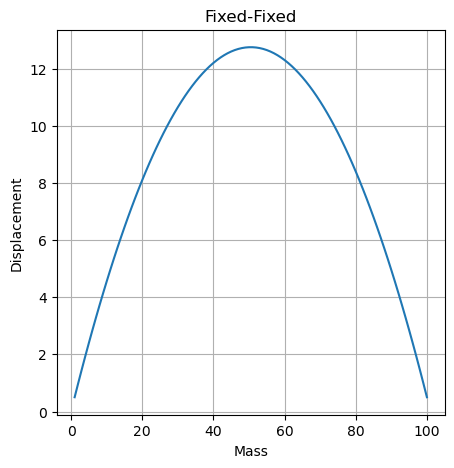

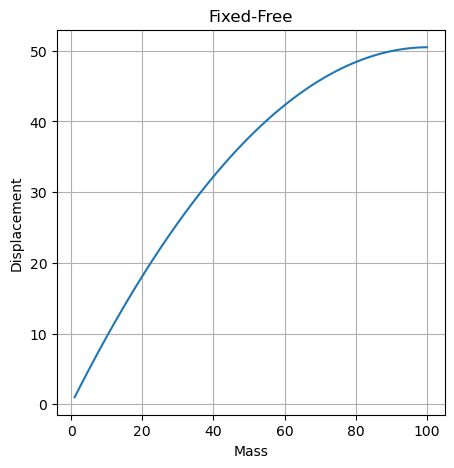

In [17]:
f = np.full(100, 0.01)

# fixed fixed
K = np.zeros((100, 100))

for i in range(100):
    K[i, i] = 2

    if i > 0:
        K[i, i-1] = -1
    if i < 99: # n-1
        K[i, i+1] = -1

u = sp.linalg.solve(K, f)
x = np.arange(1, 101) # n+1

plt.figure(figsize=(5,5))
plt.plot(x, u)
plt.title("Fixed-Fixed")
plt.xlabel("Mass")
plt.ylabel("Displacement")
plt.grid(True)

# fixed free
Kf = np.zeros((100, 100))

for i in range(100):
    if i == 0:
        Kf[i, i] = 2
        Kf[i, i+1] = -1
    elif i == n - 1:
        Kf[i, i] = 1
        Kf[i, i - 1] = -1
    else:
        Kf[i, i] = 2 * 1
        Kf[i, i - 1] = -1
        Kf[i, i + 1] = -1

uf = sp.linalg.solve(Kf, f)

plt.figure(figsize=(5,5))
plt.plot(x, uf)
plt.title("Fixed-Free")
plt.xlabel("Mass")
plt.ylabel("Displacement")
plt.grid(True)


## Section 8.1, Problem #11

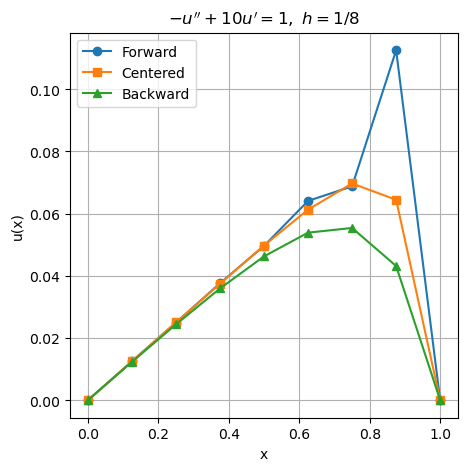

In [21]:
h = 1/8
x = np.linspace(0, 1, 9)

rhs = np.ones(7)

def solve_system(method):
    # ehh too lazy for docstrings
    A = np.zeros((7, 7))

    for i in range(7):
        # this is why we need switch cases in python!!!
        if method == "forward":
            left   = -1/h**2
            center = 2/h**2 - 10/h
            right  = -1/h**2 + 10/h

        elif method == "centered":
            left   = -1/h**2 - 5/h
            center = 2/h**2
            right  = -1/h**2 + 5/h

        elif method == "backward":
            left   = -1/h**2 - 10/h
            center = 2/h**2 + 10/h
            right  = -1/h**2

        if i > 0:
            A[i, i-1] = left

        A[i, i] = center

        if i < 6: # n-1
            A[i, i+1] = right

    u = sp.linalg.solve(A, rhs)

    # Add boundary values
    u_full = np.zeros(9)
    u_full[1:-1] = u

    return u_full

uf = solve_system("forward")
uc = solve_system("centered")
ub = solve_system("backward")

plt.figure(figsize=(5,5))

plt.plot(x, uf, 'o-', label='Forward')
plt.plot(x, uc, 's-', label='Centered')
plt.plot(x, ub, '^-', label='Backward')

plt.grid(True)
plt.legend()
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(r"$-u''+10u'=1,\ h=1/8$")
plt.show()